# 02 基线与表格模型：先跑基线，再决定要不要上 DL

> 前置：`01-data-engineering`、`04-neural-networks`（知道 DL 是什么）。
> 目标：建立工程界最重要的方法论——**先跑简单基线，再逐步升级**；并理解表格数据（tabular）上为什么树模型通常是默认最优解。

## 基线方法论

```
问题 → 最简单的可行模型（基线） → 评估 → 有提升空间吗？ → 升级模型 → 再评估
```

基线不是"敷衍"，而是：
- 给出**性价比上限的参考点**：如果随机森林 0.80，你花一个月调 CNN 到 0.82，值不值？
- 暴露**数据问题**：基线都过拟合/欠拟合 → 先回去修数据；
- 让复杂模型的增益**可测量**。

## 本课模型梯度

逻辑回归（线性）→ 决策树（非线性、可解释）→ 随机森林（Bagging 集成）→ GBDT（Boosting 集成）。每一级都在解决上一级的某个缺陷。

In [1]:
# 本模块通用导入（全部 CPU 即可运行）
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.filterwarnings("ignore")

# 中文字体兼容（Windows / macOS）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("numpy", np.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.2 | pandas 3.0.5 | sklearn 1.9.0


In [2]:
import io, urllib.request

TITANIC_URLS = [
    "https://cdn.jsdelivr.net/gh/datasciencedojo/datasets@master/titanic.csv",
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv",
]

def _read_titanic():
    """本地缓存优先，CDN 在线下载兜底；全部失败返回 None。"""
    for p in (os.path.join("..", "titanic.csv"), "titanic.csv"):
        if os.path.exists(p):
            return pd.read_csv(p)
    for url in TITANIC_URLS:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=15) as r:
                data = r.read()
            with open(os.path.join("..", "titanic.csv"), "wb") as f:
                f.write(data)
            return pd.read_csv(io.BytesIO(data))
        except Exception:
            continue
    return None

def load_titanic_features():
    """加载 Titanic 并做轻量特征工程（同 01 课思路，独立可跑）；失败回退 sklearn 内置数据。"""
    df = _read_titanic()
    if df is None:
        from sklearn.datasets import load_breast_cancer
        Xb, yb = load_breast_cancer(return_X_y=True, as_frame=True)
        df = Xb.copy(); df["target"] = yb
        print("Titanic 不可用，回退 breast_cancer（本课流程与结论不依赖特定数据）")
        return df.drop(columns=["target"]), df["target"], "breast_cancer"
    d = df.copy()
    d = d.set_index("PassengerId")
    y = d["Survived"].astype(int)
    d = d.drop(columns=["Survived"])
    d["Age"] = d["Age"].fillna(d["Age"].median())
    d["Fare"] = d["Fare"].fillna(d["Fare"].median())
    d["Embarked"] = d["Embarked"].fillna(d["Embarked"].mode()[0])
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
    d["HasCabin"] = d["Cabin"].notna().astype(int)
    d = pd.get_dummies(d, columns=["Sex", "Embarked"], drop_first=True)
    cols = ["Pclass", "Age", "Fare", "FamilySize", "HasCabin", "Sex_male", "Embarked_Q", "Embarked_S"]
    return d[cols], y, "titanic"

X, y, task = load_titanic_features()
print("任务：", task, "  特征：", X.shape)
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("训练", X_tr.shape[0], "测试", X_te.shape[0])

任务： titanic   特征： (891, 8)
训练 712 测试 179


## 三个基线的原理

**逻辑回归**（线性边界）：$P(y=1|x) = \sigma(w^\top x + b)$，用交叉熵损失训练。简单、可解释、是"线性思考"的底线。

**决策树**（轴平行分段）：每个节点按**基尼不纯度**分裂：

$$G = 1 - \sum_k p_k^2$$

每次选择使 $G$ 下降最多的特征+阈值。能表达非线性，但单棵树方差大。

**GBDT（梯度提升树）**：用 $M$ 棵小树**顺序**拟合残差 $r_m = y - \hat f_{m-1}(x)$：

$$\hat f_M(x) = \sum_{m=1}^{M} \eta \cdot h_m(x)$$

每棵树修正前序模型的错误——表格数据上公认的最强一族（XGBoost / LightGBM / sklearn HistGB 都是它）。

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    "逻辑回归": LogisticRegression(max_iter=1000),
    "决策树(depth4)": DecisionTreeClassifier(max_depth=4, random_state=0),
    "随机森林": RandomForestClassifier(n_estimators=200, random_state=0),
    "GBDT(Hist)": HistGradientBoostingClassifier(max_iter=200, random_state=0),
}
print(f"{'模型':14s} {'测试准确率':>10s} {'测试 AUC':>10s}")
for name, m in models.items():
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    print(f"{name:14s} {acc:10.4f} {auc:10.4f}")

模型                  测试准确率     测试 AUC


逻辑回归               0.7933     0.8372
决策树(depth4)        0.7821     0.8033


随机森林               0.8101     0.8451


GBDT(Hist)         0.8045     0.8286


## 表格数据为什么默认选树模型？

| 原因 | 说明 |
|------|------|
| 特征交互 | 树自动学"Age>60 且 Pclass==1"这类组合；DL 要自己设计 |
| 尺度不变 | 树不关心特征是否归一化，对离群点稳健 |
| 小数据友好 | 几千到几万行时，DL 容易过拟合，树几乎不会 |
| 可解释 | `feature_importances_`、shap 直接可用 |
| 训练快 | CPU 秒级到分钟级，无需 GPU |

**DL 什么时候才值得上**：图像/语音/文本（数据有空间或序列结构）；数据量极大（百万级+）；需要表征学习（如 LLM）。判断标准不是"DL 更高级"，而是**结构对不对、数据够不够**。

随机森林内置特征重要性（分裂收益累计）：
Embarked_Q    0.0094
Embarked_S    0.0237
HasCabin      0.0547
Pclass        0.0727
FamilySize    0.0774
Sex_male      0.2430
Age           0.2459
Fare          0.2733



GBDT 置换重要性（打乱该列后 AUC 下降量，越大越关键）：
Embarked_Q   -0.0011
HasCabin      0.0078
Embarked_S    0.0268
FamilySize    0.0346
Pclass        0.0413
Fare          0.0637
Age           0.0916
Sex_male      0.1866


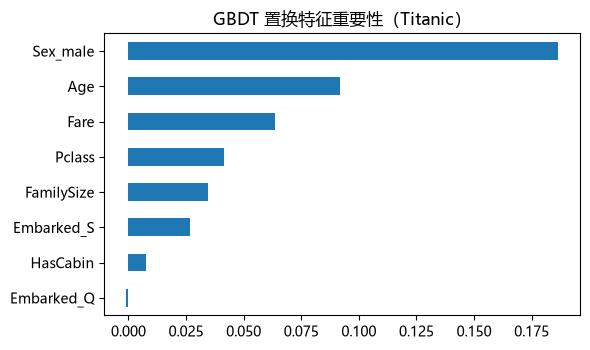

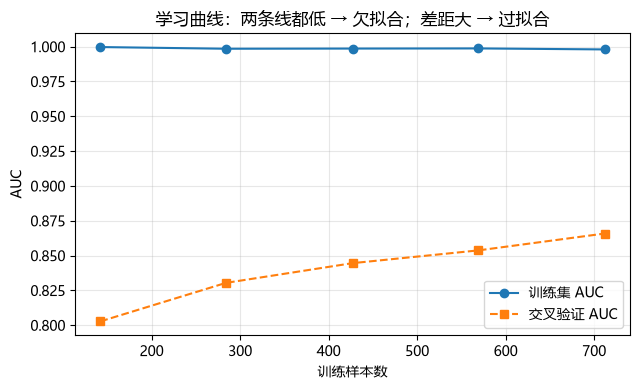

In [4]:
# 特征重要性：随机森林内置 importance + 模型无关的置换重要性（GBDT 用这个）
imp = pd.Series(models["随机森林"].feature_importances_, index=X.columns).sort_values()
print("随机森林内置特征重要性（分裂收益累计）：")
print(imp.round(4).to_string())

from sklearn.inspection import permutation_importance
perm = permutation_importance(models["GBDT(Hist)"], X_te, y_te, n_repeats=5, random_state=0)
imp2 = pd.Series(perm.importances_mean, index=X.columns).sort_values()
print("\nGBDT 置换重要性（打乱该列后 AUC 下降量，越大越关键）：")
print(imp2.round(4).to_string())
imp2.plot(kind="barh", figsize=(6, 3.6))
plt.title("GBDT 置换特征重要性（Titanic）")
plt.tight_layout(); plt.show()

# 学习曲线：数据量决定模型上限
from sklearn.model_selection import learning_curve
sizes, train_s, val_s = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=0), X, y,
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0], cv=5, scoring="roc_auc")
plt.figure(figsize=(6.5, 4))
plt.plot(sizes, train_s.mean(1), "o-", label="训练集 AUC")
plt.plot(sizes, val_s.mean(1), "s--", label="交叉验证 AUC")
plt.xlabel("训练样本数"); plt.ylabel("AUC")
plt.title("学习曲线：两条线都低 → 欠拟合；差距大 → 过拟合")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 决策框架（背下来）

```
我的数据是什么？
├─ 表格数据（行=样本，列=特征）→ 先 GBDT/随机森林；DL 只在数据巨大或要表征时
├─ 图像 → CNN/ViT（见 06-computer-vision）
├─ 文本 → Transformer（见 07-llm）
└─ 时序 → 树模型+滞后特征 或 RNN/TCN（看数据量与任务）
```

**提交格式**：Kaggle 需要固定格式的 `submission.csv`（id + 预测）。生成并验证它，是"能交付"的第一步。

In [5]:
# Kaggle 提交文件格式演示：PassengerId + Survived
sub = pd.DataFrame({"PassengerId": X_te.index, "Survived": models["随机森林"].predict(X_te)})
print(sub.head(5).to_string())
sub.to_csv("submission_demo.csv", index=False)
print("\n已生成 submission_demo.csv，共", len(sub), "行，列：", list(sub.columns))
# 校验：无缺失、类别只含 0/1
assert sub["Survived"].isin([0, 1]).all() and sub["Survived"].notna().all()
print("格式校验通过（Kaggle 可直接提交此格式）")

   PassengerId  Survived
0          566         0
1          161         0
2          554         0
3          861         0
4          242         1

已生成 submission_demo.csv，共 179 行，列： ['PassengerId', 'Survived']
格式校验通过（Kaggle 可直接提交此格式）


## 课后练习（Kaggle）

1. **Titanic 首个提交**（<https://www.kaggle.com/c/titanic>）：用本课 GBDT 思路，在 Kaggle 上跑通"训练→提交→拿公共榜分数"全流程，目标 **≥ 0.77**（用完整特征工程与 5 折交叉验证选模型即可达到）。这是你提交的第一个真实模型。
2. **House Prices 回归基线**（<https://www.kaggle.com/c/house-prices-advanced-regression-techniques>）：用随机森林预测房价（RMSE），体会回归问题与分类的差异。
3. **思考题**：为什么同一份数据，GBDT 的 AUC 高于逻辑回归？用特征重要性图解释。